<a href="https://colab.research.google.com/github/Juliethr3/taller-1-secop/blob/main/notebooks/taller_1_secop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

archivos = files.upload()

Saving secop_bienes (2).parquet to secop_bienes (2) (1).parquet


In [3]:
# Identificar el archivo Parquet cargado.
nombre_archivo = next(
    nombre for nombre in archivos
    if nombre.lower().endswith(".parquet")
)
# Leer los datos y conservar la base original sin modificar.
df_original = pd.read_parquet(nombre_archivo)
print(f"Número de filas: {df_original.shape[0]:,}")
print(f"Número de columnas: {df_original.shape[1]}")
display(df_original.head())

Número de filas: 196,391
Número de columnas: 36


,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,...,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,...,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,...,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...
3,CO1.PCCNTR.1000908,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Licitación pública,...,733992000,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
4,CO1.PCCNTR.1000911,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Bolívar,Cartagena,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,6000000,0,No Definido,No,Distribuido,Inversión,Aprobado,No,No,{'url': 'https://community.secop.gov.co/Public...


## 1. Entendimiento inicial de los datos

### 1.1. Dimensiones y estructura

El archivo contiene 196.391 registros y 36 atributos. Incluye información
sobre las entidades contratantes, los proveedores, las características
de contratación, las fechas, los valores monetarios y el estado de los
contratos.

Se examinan los tipos de datos, la cantidad de valores únicos, los
valores faltantes y las posibles duplicaciones. Esta revisión permite
evaluar la estructura de la base antes de seleccionar las variables
principales y realizar el análisis univariado.

In [4]:
# Resumen de las 36 variables.
resumen_variables = pd.DataFrame({
    "tipo_dato": df_original.dtypes.astype(str),
    "valores_no_nulos": df_original.notna().sum(),
    "valores_nulos": df_original.isna().sum(),
    "porcentaje_nulos": df_original.isna().mean() * 100,
    "valores_unicos": df_original.nunique(dropna=True)
})
resumen_variables.index.name = "variable"
display(
    resumen_variables.style.format({
        "porcentaje_nulos": "{:.3f}%"
    })
)

,tipo_dato,valores_no_nulos,valores_nulos,porcentaje_nulos,valores_unicos
variable,,,,,
id_contrato,object,196391,0,0.000%,196391
nombre_entidad,object,196391,0,0.000%,3452
departamento,object,196391,0,0.000%,34
ciudad,object,196391,0,0.000%,676
orden,object,196391,0,0.000%,4
sector,object,196391,0,0.000%,26
rama,object,196391,0,0.000%,5
entidad_centralizada,object,196391,0,0.000%,2
tipo_de_contrato,object,196391,0,0.000%,2


In [5]:
# Duplicados considerando todas las columnas.
duplicados_completos = df_original.duplicated().sum()
# Identificadores distintos, sin contar valores nulos.
contratos_identificados = df_original["id_contrato"].nunique()
# Filas con identificador presente que repiten uno anterior.
ids_presentes = df_original["id_contrato"].dropna()
repeticiones_id = ids_presentes.duplicated().sum()
print(f"Filas completamente duplicadas: {duplicados_completos:,}")
print(f"Identificadores de contrato distintos: {contratos_identificados:,}")
print(f"Repeticiones adicionales de id_contrato: {repeticiones_id:,}")
print(
    "Registros sin id_contrato:",
    df_original["id_contrato"].isna().sum()
)

Filas completamente duplicadas: 0
Identificadores de contrato distintos: 196,391
Repeticiones adicionales de id_contrato: 0
Registros sin id_contrato: 0


### Verificación de duplicados e identificadores
La base contiene 196.391 registros y 196.391 identificadores de contrato
distintos. No se encontraron filas completamente duplicadas, repeticiones
de `id_contrato` ni valores nulos en este atributo. Por tanto, cada fila
corresponde a un contrato identificado de manera única en el archivo y
no se eliminaron registros por duplicación.

Este resultado verifica la unicidad de los registros, pero no descarta
problemas de calidad en los demás atributos.

In [6]:
print(resumen_variables.to_string())

                                       tipo_dato  valores_no_nulos  valores_nulos  porcentaje_nulos  valores_unicos
variable                                                                                                           
id_contrato                               object            196391              0          0.000000          196391
nombre_entidad                            object            196391              0          0.000000            3452
departamento                              object            196391              0          0.000000              34
ciudad                                    object            196391              0          0.000000             676
orden                                     object            196391              0          0.000000               4
sector                                    object            196391              0          0.000000              26
rama                                      object            196391      

### 1.2. Tipos de datos y valores faltantes

  La base contiene 28 columnas de tipo object, cinco numéricas y tres
de fecha. Las columnas object incluyen variables categóricas,
identificadores, descripciones y enlaces; por tanto, su tipo de
almacenamiento no determina por sí solo su función en el análisis.

  Se identificaron 2.440 valores nulos en fecha_de_inicio_del_contrato
(1,242 %) y cuatro en documento_proveedor (0,002 %). Las otras 34
columnas no presentan valores nulos reconocidos por pandas.

  Se conservaron los registros y los valores nulos, sin imputación.
La ausencia de la fecha de inicio se tendrá en cuenta en los análisis
que requieran calcular duraciones. Los documentos de proveedor
faltantes no se reconstruirán sin una fuente verificable.

  La revisión se complementa con la búsqueda de cadenas vacías y
etiquetas que podrían representar información ausente.

In [7]:
# Buscar posibles faltantes escritos como texto.
# Esta revisión no modifica df_original.
etiquetas_a_revisar = {
    "", "nan", "none", "null", "na", "n/a",
    "sin información", "sin informacion",
    "no informado", "no disponible", "no definido",
    "no especificado", "no registra", "no aplica"
}
hallazgos = []
columnas_texto = df_original.select_dtypes(
    include=["object", "string"]
).columns
for columna in columnas_texto:
    texto = (
        df_original[columna]
        .astype("string")
        .str.strip()
        .str.casefold()
    )
    coincidencias = texto[
        texto.isin(etiquetas_a_revisar)
    ].value_counts()
    for etiqueta, cantidad in coincidencias.items():
        hallazgos.append({
            "variable": columna,
            "etiqueta": (
                "[cadena vacía]" if etiqueta == "" else etiqueta
            ),
            "cantidad": int(cantidad),
            "porcentaje": cantidad / len(df_original) * 100
        })
faltantes_textuales = pd.DataFrame(
    hallazgos,
    columns=["variable", "etiqueta", "cantidad", "porcentaje"]
)
if faltantes_textuales.empty:
    print("No se encontraron las etiquetas buscadas.")
else:
    faltantes_textuales = faltantes_textuales.sort_values(
        "cantidad", ascending=False
    )
    print(
        faltantes_textuales.to_string(
            index=False,
            formatters={"porcentaje": "{:.3f}%".format}
        )
    )

                        variable    etiqueta  cantidad porcentaje
          condiciones_de_entrega no definido     49971    25.445%
                          ciudad no definido     41672    21.219%
      g_nero_representante_legal no definido     35822    18.240%
        habilita_pago_adelantado no definido     28507    14.515%
           duraci_n_del_contrato no definido      9490     4.832%
                    departamento no definido      7510     3.824%
             documento_proveedor no definido      1563     0.796%
             objeto_del_contrato no definido      1109     0.565%
nacionalidad_representante_legal no definido       869     0.442%
                   destino_gasto   no aplica       532     0.271%
                   destino_gasto no definido       379     0.193%
            proveedor_adjudicado no definido       121     0.062%
                            rama no definido         9     0.005%
                          sector no definido         9     0.005%
          

### 1.3. Información ausente codificada como texto

  La revisión identificó la etiqueta “No definido” en distintos atributos.
Esta etiqueta representa información no especificada y no es detectada
como valor nulo por pandas. En consecuencia, el conteo inicial de nulos
subestima la información ausente.

  Se creó una copia de trabajo y se reemplazó “No definido” por valores
faltantes, identificando la etiqueta sin distinguir mayúsculas y
minúsculas ni espacios al inicio o al final. Se conservó intacta la
base original y no se eliminaron registros por este procedimiento.

  La etiqueta “No aplica” se mantuvo como categoría diferenciada,
pendiente de evaluar su significado en cada atributo. No se imputaron
valores.

In [8]:
# Crear una copia de trabajo. La base original permanece intacta.
df = df_original.copy(deep=True)
registro_cambios = []

for columna in columnas_texto:
    texto_normalizado = (
        df_original[columna]
        .astype("string")
        .str.strip()
        .str.casefold()
    )
    es_no_definido = texto_normalizado.eq("no definido").fillna(False)
    cantidad = int(es_no_definido.sum())

    if cantidad > 0:
        df.loc[es_no_definido, columna] = pd.NA

        registro_cambios.append({
            "variable": columna,
            "nulos_originales": int(df_original[columna].isna().sum()),
            "no_definido_convertidos": cantidad,
            "nulos_tras_tratamiento": int(df[columna].isna().sum()),
            "porcentaje_nulos_final": df[columna].isna().mean() * 100
        })
registro_cambios = pd.DataFrame(registro_cambios)

if not registro_cambios.empty:
    print(
        registro_cambios.to_string(
            index=False,
            formatters={"porcentaje_nulos_final": "{:.3f}%".format}
        )
    )
else:
    print("No se encontraron valores 'No definido'.")

print(f"\nFilas conservadas: {len(df):,}")

                        variable  nulos_originales  no_definido_convertidos  nulos_tras_tratamiento porcentaje_nulos_final
                    departamento                 0                     7510                    7510                 3.824%
                          ciudad                 0                    41672                   41672                21.219%
                           orden                 0                        9                       9                 0.005%
                          sector                 0                        9                       9                 0.005%
                            rama                 0                        9                       9                 0.005%
             objeto_del_contrato                 0                     1109                    1109                 0.565%
           duraci_n_del_contrato                 0                     9490                    9490                 4.832%
          condic

In [9]:
columnas_fecha = [
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato"
]
resumen_fechas = pd.DataFrame({
    "fecha_minima": df[columnas_fecha].min(),
    "fecha_maxima": df[columnas_fecha].max(),
    "valores_nulos": df[columnas_fecha].isna().sum()
})
print("RANGOS DE FECHAS")
print(resumen_fechas.to_string())
firma = df["fecha_de_firma"]
inicio = df["fecha_de_inicio_del_contrato"]
fin = df["fecha_de_fin_del_contrato"]
revision_fechas = pd.DataFrame({
    "comprobacion": [
        "Inicio anterior a la firma",
        "Fin anterior al inicio",
        "Fin anterior a la firma"
    ],
    "registros_evaluables": [
        (inicio.notna() & firma.notna()).sum(),
        (fin.notna() & inicio.notna()).sum(),
        (fin.notna() & firma.notna()).sum()
    ],
    "casos_detectados": [
        (inicio < firma).sum(),
        (fin < inicio).sum(),
        (fin < firma).sum()
    ]
})
print("\nPOSIBLES INCONSISTENCIAS TEMPORALES")
print(revision_fechas.to_string(index=False))
print("\nREGISTROS POR AÑO DE FIRMA")
print(
    firma.dt.year.value_counts(dropna=False)
    .sort_index()
    .rename_axis("anio_firma")
    .to_frame("registros")
    .to_string()
)

RANGOS DE FECHAS
                             fecha_minima fecha_maxima  valores_nulos
variable                                                             
fecha_de_firma                 2019-01-01   2025-12-31              0
fecha_de_inicio_del_contrato   2016-06-27   2026-12-16           2440
fecha_de_fin_del_contrato       202-12-31   2065-01-31              0

POSIBLES INCONSISTENCIAS TEMPORALES
              comprobacion  registros_evaluables  casos_detectados
Inicio anterior a la firma                193951             13047
    Fin anterior al inicio                193951               125
   Fin anterior a la firma                196391              2601

REGISTROS POR AÑO DE FIRMA
            registros
anio_firma           
2019            16425
2020            20135
2021            24043
2022            28070
2023            32971
2024            34634
2025            40113


### 1.4. Consistencia temporal

  Se identificaron 13.047 registros con fecha de inicio anterior a la
firma, 125 con fecha de fin anterior al inicio y 2.601 con fecha de fin
anterior a la firma. Estas condiciones pueden coincidir en un mismo
registro, por lo que sus frecuencias no se suman para calcular el
número de contratos afectados.

  Se conservaron los registros y se crearon indicadores de revisión,
sin modificar las fechas originales. Los cálculos de duración deberán
utilizar fechas presentes y coherentes con la definición del indicador.

  Las fechas de firma abarcan los años 2019 a 2025. La selección del
periodo analítico permanece pendiente de revisar la calidad de la
información y los estados de los contratos por año. El volumen anual,
por sí solo, no permite establecer la comparabilidad entre periodos.

In [10]:
# Booleanos anulables: una fecha ausente implica resultado desconocido.
df["alerta_inicio_antes_firma"] = (
    (inicio < firma).astype("boolean")
    .mask(inicio.isna() | firma.isna(), pd.NA)
)
df["alerta_fin_antes_inicio"] = (
    (fin < inicio).astype("boolean")
    .mask(fin.isna() | inicio.isna(), pd.NA)
)
df["alerta_fin_antes_firma"] = (
    (fin < firma).astype("boolean")
    .mask(fin.isna() | firma.isna(), pd.NA)
)
columnas_alertas = [
    "alerta_inicio_antes_firma",
    "alerta_fin_antes_inicio",
    "alerta_fin_antes_firma"
]
al_menos_una_alerta = (
    df[columnas_alertas].fillna(False).any(axis=1)
)
print(
    "Contratos con al menos una alerta temporal detectada:",
    int(al_menos_una_alerta.sum())
)

Contratos con al menos una alerta temporal detectada: 13554


In [11]:
variables_numericas = [
    "valor_del_contrato",
    "valor_pagado",
    "valor_facturado",
    "valor_pendiente_de_pago",
    "dias_adicionados"
]
resumen_numerico = df[variables_numericas].describe(
    percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]
).T
print("DISTRIBUCIÓN DE VARIABLES NUMÉRICAS")
print(resumen_numerico.to_string(float_format=lambda x: f"{x:,.2f}"))

revision_numerica = pd.DataFrame({
    "nulos": df[variables_numericas].isna().sum(),
    "negativos": df[variables_numericas].lt(0).sum(),
    "ceros": df[variables_numericas].eq(0).sum(),
    "infinitos": np.isinf(df[variables_numericas]).sum()
})
print("\nREVISIÓN DE VALORES")
print(revision_numerica.to_string())

print(
    "\nRegistros con valor pagado superior al valor del contrato:",
    int((df["valor_pagado"] > df["valor_del_contrato"]).sum())
)
# Imprimir las fechas como texto para evitar ambigüedades en la captura.
print("\nRANGOS EXACTOS DE FECHAS")
for columna in columnas_fecha:
    print(
        f"{columna}: "
        f"{df[columna].min().isoformat()} a "
        f"{df[columna].max().isoformat()}"
    )

DISTRIBUCIÓN DE VARIABLES NUMÉRICAS
                             count              mean                   std            min           25%           50%            75%            95%              99%                       max
variable                                                                                                                                                                                      
valor_del_contrato      196,391.00 65,824,255,027.86 29,015,352,967,838.23           0.00 12,021,214.00 33,600,000.00 100,000,000.00 800,000,000.00 4,118,481,942.98 12,858,450,316,000,000.00
valor_pagado            196,391.00    119,491,099.77      2,444,116,099.87           0.00          0.00          0.00  28,120,772.50 312,000,000.00 1,714,289,389.80        594,403,394,800.00
valor_facturado         196,391.00    148,409,156.65      2,969,809,583.32           0.00          0.00  3,207,328.00  37,086,225.00 384,295,956.00 2,025,784,562.80        594,503,164,818.00
valor_pen

In [12]:
columnas_revision = [
    "id_contrato",
    "nombre_entidad",
    "objeto_del_contrato",
    "fecha_de_firma",
    "estado_contrato",
    "valor_del_contrato",
    "valor_pagado",
    "valor_pendiente_de_pago",
    "urlproceso"
]
mayores_contratos = df.nlargest(5, "valor_del_contrato")
# Mostrar un contrato a la vez para evitar tablas demasiado anchas.
for _, registro in mayores_contratos[columnas_revision].iterrows():
    print("\n" + "=" * 60)
    for columna in columnas_revision:
        valor = registro[columna]
        if columna in [
            "valor_del_contrato",
            "valor_pagado",
            "valor_pendiente_de_pago"
        ]:
            print(f"{columna}: {valor:,.2f}")
        else:
            print(f"{columna}: {valor}")
total_valor = df["valor_del_contrato"].sum()
maximo_valor = df["valor_del_contrato"].max()
print(
    "\nParticipación del contrato de mayor valor en la suma registrada: "
    f"{100 * maximo_valor / total_valor:.3f}%"
)


id_contrato: CO1.PCCNTR.3102623
nombre_entidad: INSTITUTO MUNICIPAL DEL DEPORTE Y LA RECREACION DE YUMBO
objeto_del_contrato: ADQUISICION A TITULO DE COMPRAVENTA DE TRES (3) MAQUINAS: DOS TRACTORES CORTA CESPED DE 23 CABALLOS Y UNA MAQUINA GRINERA MANUAL CORTACESPED AUTOPULSADA; PARA EL MANTENIMIENTO DE LA SUPERFICIE DE JUEGO EN GRAMA NATURAL DEL ESTADIO MUNICIPAL Y MANTENIMIENTO DE LAS DEMAS ZONAS VERDES EN OTROS ESCENARIOS DEPORTIVOS Y RECREATIVOS; A CARGO DEL IMDERTY; DE ACUERDO A LAS CONDICIONES TECNICAS QUE DE CADA MAQUINA DE DESCRIBEN Y DETALLAN EN LAS ESPECIFICACIONES TECNICAS.
fecha_de_firma: 2021-12-09 00:00:00
estado_contrato: En ejecución
valor_del_contrato: 12,858,450,316,000,000.00
valor_pagado: 0.00
valor_pendiente_de_pago: 12,858,450,316,000,000.00
urlproceso: {'url': 'https://community.secop.gov.co/Public/Tendering/OpportunityDetail/Index?noticeUID=CO1.NTC.2419525&isFromPublicArea=True&isModal=true&asPopupView=true'}

id_contrato: CO1.PCCNTR.7379758
nombre_entidad: MIN

In [13]:
print("CINCO REGISTROS CON MÁS DÍAS ADICIONADOS")
columnas_plazo = [
    "id_contrato",
    "dias_adicionados",
    "duraci_n_del_contrato",
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
    "estado_contrato"
]
print(
    df.nlargest(5, "dias_adicionados")[columnas_plazo]
    .to_string(index=False)
)
print("\nCINCO FECHAS DE FIN MÁS ANTIGUAS")

columnas_fechas_revision = [
    "id_contrato",
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
    "estado_contrato"
]
print(
    df.nsmallest(5, "fecha_de_fin_del_contrato")[
        columnas_fechas_revision
    ].to_string(index=False)
)

CINCO REGISTROS CON MÁS DÍAS ADICIONADOS
       id_contrato  dias_adicionados duraci_n_del_contrato fecha_de_firma fecha_de_inicio_del_contrato fecha_de_fin_del_contrato estado_contrato
CO1.PCCNTR.8596968             14276             45 Dia(s)     2025-11-14                   2025-11-14                2065-01-31      Modificado
CO1.PCCNTR.4337295               874              3 Año(s)     2022-12-27                   2022-12-27                2028-12-21      Modificado
CO1.PCCNTR.8298580               770             50 Dia(s)     2025-09-10                   2025-09-15                2027-11-04       terminado
CO1.PCCNTR.6467201               731             2 Mes(es)     2024-06-27                   2024-06-27                2024-08-20      Modificado
CO1.PCCNTR.5864414               730              4 Año(s)     2024-02-02                   2024-02-02                2028-02-02      Modificado

CINCO FECHAS DE FIN MÁS ANTIGUAS
       id_contrato fecha_de_firma fecha_de_inicio_del_c

In [14]:
estado_revision = (
    df["estado_contrato"]
    .astype("string")
    .str.strip()
    .str.casefold()
    .fillna("sin información")
)
estados_por_anio = pd.crosstab(
    df["fecha_de_firma"].dt.year,
    estado_revision
)
porcentajes_por_anio = (
    estados_por_anio
    .div(estados_por_anio.sum(axis=1), axis=0)
    .mul(100)
)
print("NÚMERO DE CONTRATOS POR AÑO Y ESTADO")
print(estados_por_anio.to_string())
print("\nPORCENTAJES DENTRO DE CADA AÑO")
print(porcentajes_por_anio.round(2).to_string())

NÚMERO DE CONTRATOS POR AÑO Y ESTADO
estado_contrato  aprobado  borrador  cancelado  cedido  cerrado  en ejecución  modificado  suspendido  terminado
fecha_de_firma                                                                                                  
2019                 5321         1          1       4     5828             0        2416           7       2847
2020                 1722         0          3       4     7170          3816        3078           7       4335
2021                  468         0          2       5     7624          5984        3458          11       6491
2022                  418         0         12       2     8320          7129        3926          10       8253
2023                  427         0          6       5     7122          9546        5487          17      10361
2024                  396         0          1      12     6848          9918        6027          28      11404
2025                  459         0          1      11     

In [15]:
# Identificar el caso monetario inspeccionado.
# Se usa el máximo observado para evitar errores al transcribir el ID.
df["alerta_valor_extremo_inspeccionado"] = (
    df["valor_del_contrato"].eq(
        df_original["valor_del_contrato"].max()
    )
)
# Versión monetaria para el análisis principal.
# Se excluye el valor del caso inspeccionado, no el contrato completo.
df["valor_contrato_analisis"] = df["valor_del_contrato"].mask(
    df["alerta_valor_extremo_inspeccionado"]
)
# El saldo pendiente del mismo registro también queda en revisión.
df["saldo_pendiente_analisis"] = df["valor_pendiente_de_pago"].mask(
    df["alerta_valor_extremo_inspeccionado"]
)
# Marcar la fecha del año 0202 observada en la inspección.
df["alerta_fin_anio_0202"] = (
    df["fecha_de_fin_del_contrato"].dt.year.eq(202)
)
df["fecha_fin_analisis"] = df["fecha_de_fin_del_contrato"].mask(
    df["alerta_fin_anio_0202"]
)
# Conservar los días originales y crear una versión para sensibilidad.
df["alerta_adicion_14276_dias"] = df["dias_adicionados"].eq(14276)
df["dias_adicionados_sensibilidad"] = df["dias_adicionados"].mask(
    df["alerta_adicion_14276_dias"]
)
# Alertas adicionales: no se corrigen automáticamente.
df["alerta_valor_cero"] = df["valor_del_contrato"].eq(0)
df["alerta_pago_superior_valor"] = (
    df["valor_pagado"] > df["valor_del_contrato"]
)
df["alerta_saldo_negativo"] = df["valor_pendiente_de_pago"].lt(0)
print("Filas conservadas:", len(df))
print(
    "Valores monetarios apartados del análisis principal:",
    int(df["alerta_valor_extremo_inspeccionado"].sum())
)
print(
    "Fechas de fin del año 0202:",
    int(df["alerta_fin_anio_0202"].sum())
)
print(
    "Registros con 14.276 días adicionados:",
    int(df["alerta_adicion_14276_dias"].sum())
)

Filas conservadas: 196391
Valores monetarios apartados del análisis principal: 1
Fechas de fin del año 0202: 1
Registros con 14.276 días adicionados: 1


In [16]:
def resumen_serie(serie):
    return pd.Series({
        "n_validos": serie.count(),
        "media": serie.mean(),
        "mediana": serie.median(),
        "percentil_99": serie.quantile(0.99),
        "maximo": serie.max()
    })
comparacion_valores = pd.DataFrame({
    "valor_original": resumen_serie(df["valor_del_contrato"]),
    "sin_caso_monetario_inspeccionado": resumen_serie(
        df["valor_contrato_analisis"]
    )
}).T
comparacion_dias = pd.DataFrame({
    "dias_originales": resumen_serie(df["dias_adicionados"]),
    "sin_caso_de_14276_dias": resumen_serie(
        df["dias_adicionados_sensibilidad"]
    )
}).T
print("SENSIBILIDAD DEL VALOR CONTRACTUAL")
print(comparacion_valores.to_string(float_format=lambda x: f"{x:,.2f}"))
print("\nSENSIBILIDAD DE LOS DÍAS ADICIONADOS")
print(comparacion_dias.to_string(float_format=lambda x: f"{x:,.2f}"))

SENSIBILIDAD DEL VALOR CONTRACTUAL
                                  n_validos             media       mediana     percentil_99                    maximo
valor_original                   196,391.00 65,824,255,027.86 33,600,000.00 4,118,481,942.98 12,858,450,316,000,000.00
sin_caso_monetario_inspeccionado 196,390.00    350,531,866.07 33,600,000.00 4,116,699,459.70      2,846,224,257,835.00

SENSIBILIDAD DE LOS DÍAS ADICIONADOS
                        n_validos  media  mediana  percentil_99    maximo
dias_originales        196,391.00   5.11     0.00        122.00 14,276.00
sin_caso_de_14276_dias 196,390.00   5.03     0.00        122.00    874.00


### 1.5. Selección de cinco atributos principales

Se seleccionaron cinco atributos por su relación con el objetivo de
supervisión:

| Atributo | Justificación |
|---|---|
| Valor del contrato | Describe la magnitud económica del compromiso y permite examinar su distribución y concentración. |
| Valor pagado | Describe los desembolsos registrados. Su interpretación requiere considerar el valor y el estado del contrato. |
| Días adicionados | Permite caracterizar la frecuencia y magnitud de las ampliaciones de plazo registradas. |
| Modalidad de contratación | Permite identificar cómo se distribuyen los contratos entre los mecanismos de contratación. |
| Estado del contrato | Describe su situación administrativa y proporciona contexto para interpretar pagos y ampliaciones de plazo. |

Esta selección no excluye el uso posterior de sector, destino del gasto,
liquidación u otros atributos en el análisis multivariado.

La descripción inicial comprende los registros de 2019–2025. Para el
valor contractual se utiliza la versión que omite el dato monetario
presuntamente erróneo identificado en la inspección. Los valores pagados
y los días adicionados se describen tal como fueron registrados; para
estos últimos se presenta adicionalmente el análisis de sensibilidad.

In [17]:
atributos_numericos = {
    "Valor del contrato — versión de análisis": "valor_contrato_analisis",
    "Valor pagado — registrado": "valor_pagado",
    "Días adicionados — registrados": "dias_adicionados"
}
filas_resumen = []
for nombre, columna in atributos_numericos.items():
    serie = df[columna].dropna()
    filas_resumen.append({
        "atributo": nombre,
        "n_validos": len(serie),
        "n_faltantes": int(df[columna].isna().sum()),
        "media": serie.mean(),
        "desviacion_estandar": serie.std(),
        "minimo": serie.min(),
        "Q1": serie.quantile(0.25),
        "mediana": serie.median(),
        "Q3": serie.quantile(0.75),
        "P95": serie.quantile(0.95),
        "P99": serie.quantile(0.99),
        "maximo": serie.max(),
        "porcentaje_ceros_validos": serie.eq(0).mean() * 100
    })
tabla_univariada_numerica = pd.DataFrame(
    filas_resumen
).set_index("atributo")

# Mostrar un atributo por bloque para facilitar la lectura.
for atributo, resultados in tabla_univariada_numerica.iterrows():
    print(f"\n{atributo.upper()}")
    print(resultados.to_string(float_format=lambda x: f"{x:,.2f}"))
dias_positivos = df.loc[
    df["dias_adicionados"] > 0, "dias_adicionados"
]
print("\nCONTRATOS CON DÍAS ADICIONADOS POSITIVOS")
print(f"Número: {len(dias_positivos):,}")
print(
    "Porcentaje entre registros con dato disponible: "
    f"{100 * len(dias_positivos) / df['dias_adicionados'].count():.2f}%"
)
print(f"Mediana entre los que tienen adiciones: {dias_positivos.median():.2f} días")


VALOR DEL CONTRATO — VERSIÓN DE ANÁLISIS
n_validos                            196,390.00
n_faltantes                                1.00
media                            350,531,866.07
desviacion_estandar           10,701,396,954.70
minimo                                     0.00
Q1                                12,020,821.00
mediana                           33,600,000.00
Q3                               100,000,000.00
P95                              800,000,000.00
P99                            4,116,699,459.70
maximo                     2,846,224,257,835.00
porcentaje_ceros_validos                   0.10

VALOR PAGADO — REGISTRADO
n_validos                          196,391.00
n_faltantes                              0.00
media                          119,491,099.77
desviacion_estandar          2,444,116,099.87
minimo                                   0.00
Q1                                       0.00
mediana                                  0.00
Q3                              2

In [18]:
atributos_numericos = {
    "Valor del contrato — versión de análisis": "valor_contrato_analisis",
    "Valor pagado — registrado": "valor_pagado",
    "Días adicionados — registrados": "dias_adicionados"
}
filas_resumen = []
for nombre, columna in atributos_numericos.items():
    serie = df[columna].dropna()
    filas_resumen.append({
        "atributo": nombre,
        "n_validos": len(serie),
        "n_faltantes": int(df[columna].isna().sum()),
        "media": serie.mean(),
        "desviacion_estandar": serie.std(),
        "minimo": serie.min(),
        "Q1": serie.quantile(0.25),
        "mediana": serie.median(),
        "Q3": serie.quantile(0.75),
        "P95": serie.quantile(0.95),
        "P99": serie.quantile(0.99),
        "maximo": serie.max(),
        "porcentaje_ceros_validos": serie.eq(0).mean() * 100
    })
tabla_univariada_numerica = pd.DataFrame(
    filas_resumen
).set_index("atributo")
# Mostrar un atributo por bloque para facilitar la lectura.
for atributo, resultados in tabla_univariada_numerica.iterrows():
    print(f"\n{atributo.upper()}")
    print(resultados.to_string(float_format=lambda x: f"{x:,.2f}"))
dias_positivos = df.loc[
    df["dias_adicionados"] > 0, "dias_adicionados"
]
print("\nCONTRATOS CON DÍAS ADICIONADOS POSITIVOS")
print(f"Número: {len(dias_positivos):,}")
print(
    "Porcentaje entre registros con dato disponible: "
    f"{100 * len(dias_positivos) / df['dias_adicionados'].count():.2f}%"
)
print(f"Mediana entre los que tienen adiciones: {dias_positivos.median():.2f} días")


VALOR DEL CONTRATO — VERSIÓN DE ANÁLISIS
n_validos                            196,390.00
n_faltantes                                1.00
media                            350,531,866.07
desviacion_estandar           10,701,396,954.70
minimo                                     0.00
Q1                                12,020,821.00
mediana                           33,600,000.00
Q3                               100,000,000.00
P95                              800,000,000.00
P99                            4,116,699,459.70
maximo                     2,846,224,257,835.00
porcentaje_ceros_validos                   0.10

VALOR PAGADO — REGISTRADO
n_validos                          196,391.00
n_faltantes                              0.00
media                          119,491,099.77
desviacion_estandar          2,444,116,099.87
minimo                                   0.00
Q1                                       0.00
mediana                                  0.00
Q3                              2

In [19]:
def tabla_frecuencias(serie):
    # Unificar espacios externos y mayúsculas/minúsculas.
    categorias = (
        serie.astype("string")
        .str.strip()
        .str.casefold()
        .fillna("sin información")
    )
    frecuencias = categorias.value_counts(dropna=False)

    return pd.DataFrame({
        "frecuencia": frecuencias,
        "porcentaje_total": frecuencias / len(serie) * 100
    }).rename_axis("categoria")
tabla_modalidad = tabla_frecuencias(df["modalidad_de_contratacion"])
tabla_estado = tabla_frecuencias(df["estado_contrato"])
print("MODALIDAD DE CONTRATACIÓN")
print(
    tabla_modalidad.to_string(
        formatters={"porcentaje_total": "{:.2f}%".format}
    )
)
print("\nESTADO DEL CONTRATO")
print(
    tabla_estado.to_string(
        formatters={"porcentaje_total": "{:.2f}%".format}
    )
)

MODALIDAD DE CONTRATACIÓN
                                                             frecuencia porcentaje_total
categoria                                                                               
mínima cuantía                                                   117753           59.96%
selección abreviada subasta inversa                               32907           16.76%
contratación régimen especial                                     19250            9.80%
selección abreviada de menor cuantía                               8822            4.49%
contratación régimen especial (con ofertas)                        6154            3.13%
contratación directa (con ofertas)                                 5001            2.55%
contratación directa                                               3938            2.01%
licitación pública                                                 2330            1.19%
seleccion abreviada menor cuantia sin manifestacion interes         236            0

### 1.6. Interpretación del análisis univariado

  El valor contractual presenta una distribución asimétrica hacia valores
altos. Después de apartar el dato monetario presuntamente erróneo, la
media es de 350,53 millones y la mediana de 33,6 millones. El percentil
95 es de 800 millones. Por tanto, la media debe interpretarse junto
con la mediana y los percentiles; la exclusión del caso inspeccionado
no implica que todos los valores restantes estén validados.

  El valor pagado presenta una mediana de cero y una media de 119,49
millones. El 54,81 % de los registros consigna pagos iguales a cero.
Esta concentración exige considerar el estado contractual y las
limitaciones del registro administrativo antes de interpretar
posibles desviaciones. Los pagos registrados no equivalen, por sí
solos, a una medida de ejecución física del contrato.

  El 90,49 % de los contratos registra cero días adicionados y el
9,51 % presenta adiciones positivas. Entre estos últimos, la mediana
es de 31 días. La mediana global de cero refleja la concentración
en contratos sin adiciones registradas, pero no describe la magnitud
de las ampliaciones entre quienes sí las presentan. Se conserva
el análisis de sensibilidad del caso con 14.276 días adicionados.

  La modalidad más frecuente es mínima cuantía (59,96 %), seguida
de selección abreviada por subasta inversa (16,76 %) y contratación
de régimen especial (9,80 %). Estas frecuencias describen la
composición de la base y no constituyen evidencia de mayor riesgo
en alguna modalidad.

  Los estados más frecuentes son terminado (27,61 %), en ejecución
(26,19 %), cerrado (23,84 %) y modificado (17,55 %). La coexistencia
de distintas situaciones administrativas requiere definir
poblaciones comparables para evaluar los resultados de ejecución.
El estado “modificado” no identifica por sí solo una ampliación
de plazo, y “cerrado” no debe equipararse automáticamente con
“liquidado”.

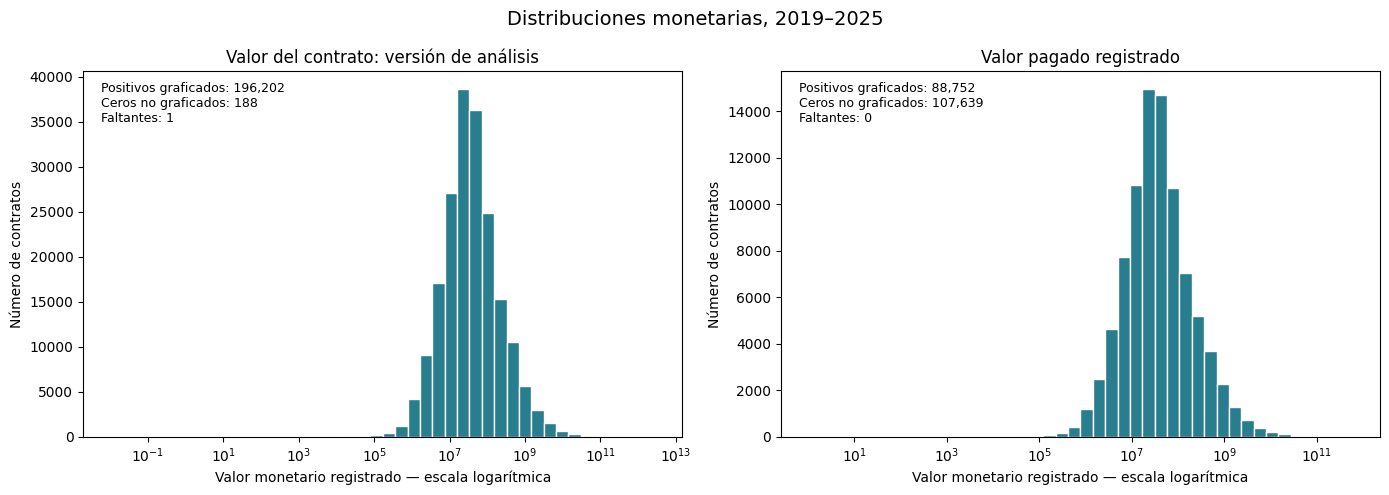

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
configuracion = [
    ("valor_contrato_analisis", "Valor del contrato: versión de análisis"),
    ("valor_pagado", "Valor pagado registrado")
]
for eje, (columna, titulo) in zip(ejes, configuracion):
    serie = df[columna]
    positivos = serie[serie > 0]
    limites = np.geomspace(
        positivos.min(), positivos.max(), 45
    )
    eje.hist(
        positivos,
        bins=limites,
        color="#287D8E",
        edgecolor="white"
    )
    eje.set_xscale("log")
    eje.set_title(titulo)
    eje.set_xlabel("Valor monetario registrado — escala logarítmica")
    eje.set_ylabel("Número de contratos")
    eje.text(
        0.03, 0.97,
        f"Positivos graficados: {len(positivos):,}\n"
        f"Ceros no graficados: {int(serie.eq(0).sum()):,}\n"
        f"Faltantes: {int(serie.isna().sum()):,}",
        transform=eje.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="none")
    )
fig.suptitle("Distribuciones monetarias, 2019–2025", fontsize=14)
plt.tight_layout()
plt.show()

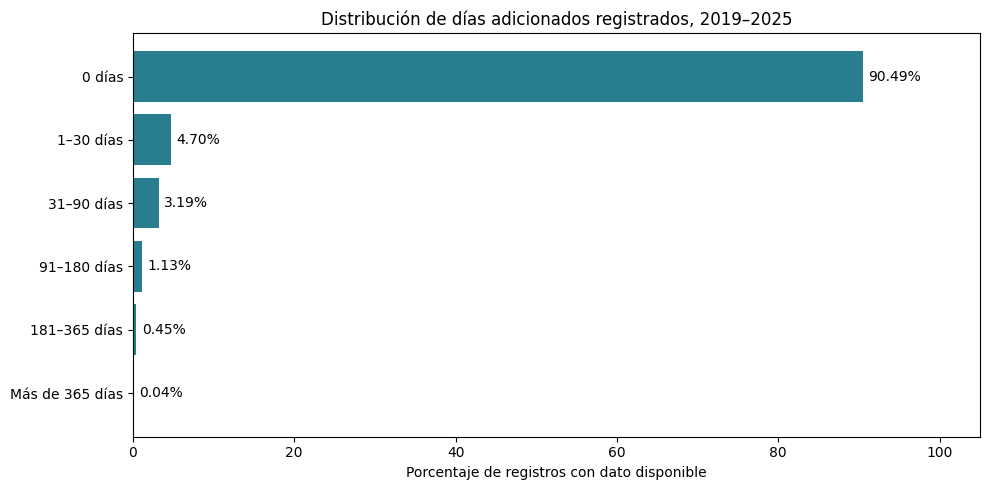

In [21]:
intervalos = [-np.inf, 0, 30, 90, 180, 365, np.inf]
etiquetas = [
    "0 días", "1–30 días", "31–90 días",
    "91–180 días", "181–365 días", "Más de 365 días"
]
grupos_dias = pd.cut(
    df["dias_adicionados"],
    bins=intervalos,
    labels=etiquetas
)
frecuencias_dias = (
    grupos_dias.value_counts(sort=False)
    .reindex(etiquetas, fill_value=0)
)
porcentajes_dias = (
    frecuencias_dias / df["dias_adicionados"].notna().sum() * 100
)
fig, eje = plt.subplots(figsize=(10, 5))
barras = eje.barh(
    etiquetas, porcentajes_dias,
    color="#287D8E"
)
eje.invert_yaxis()
eje.set_xlim(0, 105)
eje.set_xlabel("Porcentaje de registros con dato disponible")
eje.set_title("Distribución de días adicionados registrados, 2019–2025")
eje.bar_label(
    barras,
    labels=[f"{p:.2f}%" for p in porcentajes_dias],
    padding=4
)
plt.tight_layout()
plt.show()

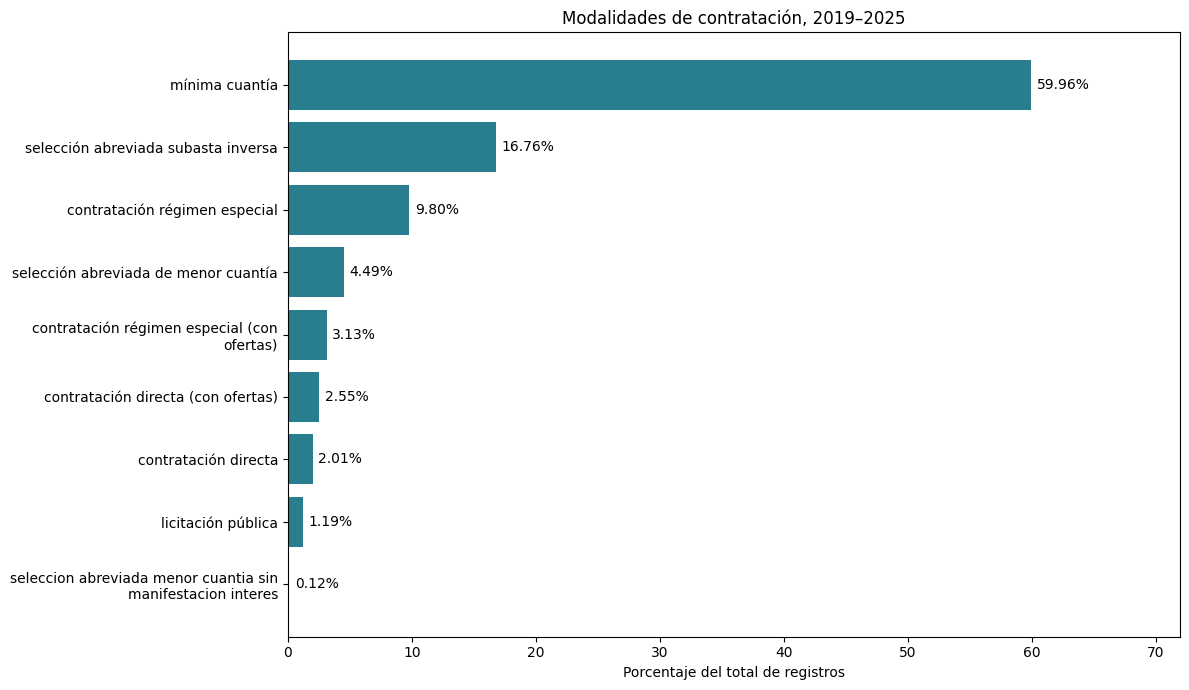

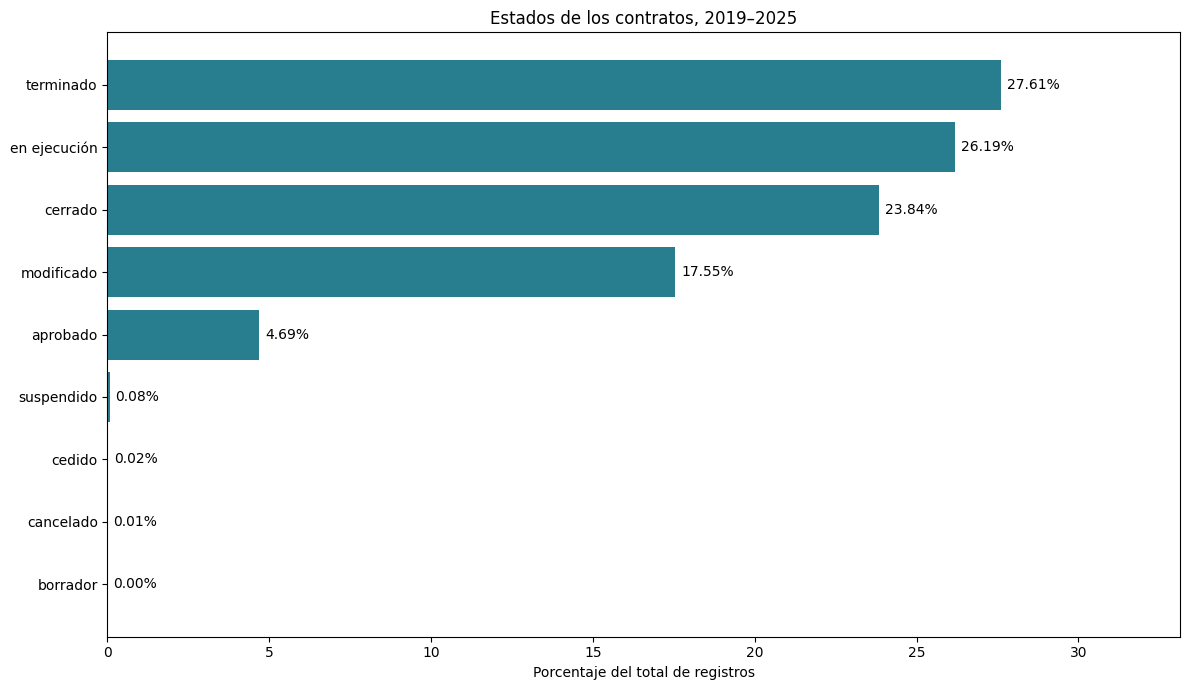

In [22]:
def graficar_categorias(tabla, titulo):
    datos = tabla.sort_values("porcentaje_total", ascending=True)
    etiquetas = [
        textwrap.fill(str(categoria), width=42)
        for categoria in datos.index
    ]
    fig, eje = plt.subplots(figsize=(12, 7))

    barras = eje.barh(
        etiquetas,
        datos["porcentaje_total"],
        color="#287D8E"
    )
    eje.bar_label(
        barras,
        labels=[
            f"{p:.2f}%"
            for p in datos["porcentaje_total"]
        ],
        padding=4
    )
    eje.set_xlim(0, datos["porcentaje_total"].max() * 1.20)
    eje.set_xlabel("Porcentaje del total de registros")
    eje.set_title(titulo)

    plt.tight_layout()
    plt.show()
graficar_categorias(
    tabla_modalidad,
    "Modalidades de contratación, 2019–2025"
)
graficar_categorias(
    tabla_estado,
    "Estados de los contratos, 2019–2025"
)

### 1.7. Reporte breve de entendimiento inicial

  La base contiene 196.391 registros de contratos con fechas de firma
entre 2019 y 2025 y 36 atributos originales: 28 columnas de tipo
object, cinco numéricas y tres de fecha. Las columnas object incluyen
categorías, identificadores, descripciones y enlaces. Se verificaron
196.391 identificadores de contrato distintos, sin identificadores
nulos ni filas completamente duplicadas.

 Se seleccionaron cinco atributos principales: valor del contrato,
valor pagado, días adicionados, modalidad de contratación y estado
del contrato. Estos permiten describir la magnitud económica,
los pagos registrados, las ampliaciones de plazo y el contexto
administrativo necesario para interpretar la ejecución.

 Tras apartar un valor contractual presuntamente erróneo, la media
del valor contractual es de 350,53 millones y la mediana de
33,6 millones. La diferencia evidencia una marcada asimetría
hacia valores altos. La exclusión se aplicó al dato monetario,
sin eliminar el contrato, y se documentó mediante un análisis
de sensibilidad.

 El 54,81 % de los registros presenta valor pagado igual a cero.
Esta condición no se interpreta automáticamente como incumplimiento,
pues requiere considerar el estado contractual y la calidad del
registro. El 9,51 % presenta días adicionados positivos; entre estos
contratos, la mediana de la adición es de 31 días.

 La modalidad predominante es mínima cuantía (59,96 %), seguida de
selección abreviada por subasta inversa (16,76 %). Los estados más
frecuentes son terminado (27,61 %), en ejecución (26,19 %) y cerrado
(23,84 %). Estas distribuciones describen la composición del archivo,
pero no permiten atribuir mayor riesgo a una categoría.

 La revisión identificó información ausente codificada como texto,
inconsistencias temporales y valores monetarios y de plazo que
requieren cautela. Se conservaron las 196.391 filas y la base
original sin modificaciones. Las transformaciones se implementaron
en una copia de trabajo, con indicadores de revisión y versiones
analíticas de las variables afectadas.

 La descripción inicial comprende 2019–2025. La delimitación temporal
y los criterios de elegibilidad para analizar desviaciones se
establecerán en la estrategia de análisis, considerando las
diferencias de estado contractual entre años y la falta de una
fecha de corte confirmada.

### 1.8. Síntesis de calidad de datos y tratamiento

| Hallazgo | Evidencia | Tratamiento aplicado |
|---|---|---|
| Duplicación | No se encontraron filas completas duplicadas ni identificadores repetidos. | No se eliminaron registros por duplicación. |
| Nulos originales | 2.440 fechas de inicio ausentes y cuatro documentos de proveedor ausentes. | Se conservaron sin imputación. |
| Ausencias codificadas como texto | “No definido” aparece en diversos atributos. | Se convirtió en valor faltante en la copia de trabajo, conservando la base original. |
| Categoría “No aplica” | Presente en algunos atributos. | Se conservó diferenciada; su significado requiere interpretación según la variable. |
| Inconsistencias temporales | 13.047 inicios anteriores a la firma, 125 finales anteriores al inicio y 2.601 finales anteriores a la firma. Los grupos pueden solaparse. | Se crearon alertas, sin corregir fechas ni eliminar filas. Su uso en duraciones requiere filtros de consistencia. |
| Finalización en el año 0202 | Un registro identificado. | Se sustituyó por un valor ausente únicamente en fecha_fin_analisis. |
| Valor monetario presuntamente erróneo | Un contrato concentra el 99,467 % de la suma original y presenta una magnitud incompatible con su objeto descrito. | Se apartaron su valor contractual y saldo pendiente en las versiones analíticas, sin imputar cifras ni eliminar la fila. Se compararon los resúmenes con y sin el valor. |
| Adición de plazo excepcional | Un registro presenta 14.276 días adicionados. | Se conservó el dato original y se creó una versión alternativa sin ese valor para el análisis de sensibilidad. |
| Valor contractual cero | 188 registros. | Se conservaron y marcaron. No deben utilizarse como denominador de una proporción pagada. |
| Pago superior al valor contractual | 177 registros. | Se marcaron para revisión, sin corrección automática. |
| Saldo pendiente negativo | 144 registros. | Se marcaron para revisión, sin corrección automática. |
| Pago registrado igual a cero | 107.639 registros. | Se conservó el cero; no se reclasificó automáticamente como faltante o incumplimiento. |
| Diferencias de estados entre años | La composición administrativa cambia según el año de firma. | Se describieron por año; la selección de la población analítica permanece pendiente. |

   Las alertas de calidad no constituyen evidencia de irregularidad
contractual. Apartar el valor monetario inspeccionado tampoco
equivale a validar todos los demás importes. Las decisiones
posteriores deberán precisar las exclusiones por indicador y
sus respectivos denominadores.